In [1]:
import matplotlib.pyplot as plt

plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
from datetime import date

import jax

rng_key = jax.random.key(int(date.today().strftime("%Y%m%d")))
from functools import partial
from typing import Callable, NamedTuple, Optional

import jax
import jax.numpy as jnp
import numpy as np
from jax.scipy.stats import multivariate_normal

import blackjax
import blackjax.smc as smc
import blackjax.smc.from_mcmc as smc_from_mcmc
import blackjax.smc.resampling as resampling
from blackjax import smc
from blackjax.base import SamplingAlgorithm
from blackjax.smc import extend_params
from blackjax.smc.base import SMCInfo, SMCState, update_and_take_last
from blackjax.types import Array, ArrayLikeTree, ArrayTree, PRNGKey

In [2]:
def V(x):
    return 5 * jnp.square(jnp.sum(x**2, axis=-1) - 1)


def prior_log_prob(x):
    d = x.shape[-1]
    return multivariate_normal.logpdf(x, jnp.zeros((d,)), jnp.eye(d))

In [156]:
from blackjax.smc.from_mcmc import unshared_parameters_and_step_fn
import blackjax.smc.ess as ess
import blackjax.smc.solver as solver
import blackjax.smc.tempered as tempered


class PersistentSMCState(NamedTuple):
    particles: ArrayTree
    likelihoods: ArrayTree
    # Z: Array
    iteration: int
    lmbda_schedule: Array
    Zs: Array


def init(particles: ArrayLikeTree):
    num_particles = particles.shape[0]
    particles = {0: particles}
    likelihoods = {}
    # num_particles = jax.tree_util.tree_flatten(particles)[0][0].shape[0]
    # weights = jnp.ones(num_particles) / num_particles
    return PersistentSMCState(particles, likelihoods, iteration=0, lmbda_schedule=[0.], Zs={0: jnp.log(1)})


def build_kernel(
    logprior_fn: Callable,
    loglikelihood_fn: Callable,
    mcmc_step_fn: Callable,
    # mcmc_init_fn: Callable,
    resampling_fn: Callable,
    # update_strategy: Callable = update_and_take_last,
    # update_particles_fn: Optional[Callable] = None,
    # lmbda_schedule: Array,
) -> Callable:
    def compute_delta(lmbda: float, particles) -> float:
        max_delta = 1 - lmbda
        delta = ess.ess_solver(
            jax.vmap(loglikelihood_fn),
            particles,
            target_ess=0.1,
            max_delta=max_delta,
            root_solver=solver.dichotomy,
        )
        delta = jnp.clip(delta, 0.0, max_delta)

        return delta

    def kernel(
        rng_key: PRNGKey,
        state: PersistentSMCState,
        num_mcmc_steps: int,
        # mcmc_parameters: dict,
    ) -> tuple[PersistentSMCState, smc.base.SMCInfo]:
        kernel_key, resampling_key = jax.random.split(rng_key)

        flat_particles = jnp.stack(
            jax.tree.leaves(state.particles), axis=0
        )  # (num_iterations, num_particles, num_dimensions)
        flat_Zs = jnp.stack(jax.tree.leaves(state.Zs), axis=0)  # (num_iterations,)
        num_iterations, num_particles, num_dimensions = tuple(flat_particles.shape)

        delta = compute_delta(
            lmbda=state.lmbda_schedule[state.iteration],
            particles=flat_particles.reshape(
                num_iterations * num_particles, num_dimensions
            ),
        )
        print(delta, "delta")
        ###################
        # calculate weights
        ###################
        state = state._replace(
            likelihoods=state.likelihoods
            | {state.iteration: jax.vmap(loglikelihood_fn)(flat_particles[-1, :, :]),
               }, lmbda_schedule=state.lmbda_schedule + [delta]
        )
        flat_likelihoods = jnp.stack(jax.tree.leaves(state.likelihoods), axis=0)
        print(flat_likelihoods.shape, "flat_likelihoods")

        # numerator = lmbda_schedule[state.iteration + 1] * jax.vmap(
        #     jax.vmap(loglikelihood_fn)
        # )(flat_particles)

        numerator = state.lmbda_schedule[state.iteration + 1] * flat_likelihoods

        denom = jax.vmap(
            jax.vmap(
                lambda loglikelihood_fn_theta: -jnp.log(
                    state.iteration + 1
                )  # note that I'm 0-indexing, unlike pseudocode
                - jax.scipy.special.logsumexp(
                    jnp.array(
                        [
                            state.lmbda_schedule[i] * loglikelihood_fn_theta - flat_Zs[i]
                            for i in range(
                                state.iteration + 1
                            )  # note that I'm 0-indexing, unlike pseudocode
                        ]
                    )
                )
            )
        )(flat_likelihoods)
        log_weights = numerator - denom  # (num_iterations, num_particles)

        new_Z = -jnp.log(
            (state.iteration) * num_particles
        ) + jax.scipy.special.logsumexp(log_weights)
        state = state._replace(Zs=state.Zs | {state.iteration + 1: new_Z})

        weights = log_weights - new_Z  # (num_iterations, num_particles)
        print(new_Z, "new_Z")
        print(log_weights, "log_weights")

        ###################
        # do resampling
        ###################

        ## consider using multinomial not systematic
        resampling_idx = resampling_fn(
            resampling_key,
            weights.reshape(num_iterations * num_particles),
            num_particles,
        )
        resampled_particles = flat_particles.reshape(
            num_iterations * num_particles, num_dimensions
        )[resampling_idx]

        ####################################
        # update particles with MCMC kernel
        ####################################

        def tempered_logposterior_fn(position: ArrayLikeTree) -> float:
            logprior = logprior_fn(position)
            tempered_loglikelihood = (
                loglikelihood_fn(position) * state.lmbda_schedule[state.iteration + 1]
            )
            return logprior + tempered_loglikelihood

        hmc_parameters = extend_params(
            dict(
                step_size=1e-2,
                inverse_mass_matrix=jnp.eye(1),
                num_integration_steps=100,
            )
        )
        unshared_mcmc_parameters, shared_mcmc_step_fn = unshared_parameters_and_step_fn(
            hmc_parameters, blackjax.hmc.build_kernel()
        )
        kernel, n_particles = update_and_take_last(
            blackjax.hmc.init,
            tempered_logposterior_fn,
            shared_mcmc_step_fn,
            num_mcmc_steps,
            num_particles,
        )
        print("n", n_particles, num_particles)

        new_particles, info = kernel(
            jax.random.split(kernel_key, num_particles),
            resampled_particles,
            unshared_mcmc_parameters,
        )
        return (
            state._replace(
                particles=state.particles | {state.iteration + 1: new_particles},
                iteration=state.iteration + 1,
            ),
            info,
        )

    return kernel

In [157]:
from blackjax.smc.persistent import build_kernel as build_kernel_persistent

init_key = jax.random.key(0)
num_particles = 100
initial_particles = jnp.zeros((num_particles, 1)) - 1
initial_smc_state = init(initial_particles)

resampling_fn = resampling.multinomial

# lmbda_schedule = jnp.array(
#     [0.003, 0.007, 0.015, 0.02, 0.04, 0.08, 0.12, 0.2, 0.3, 0.5, 0.79, 1.0]
# )
kernel = build_kernel(
    logprior_fn=prior_log_prob,
    loglikelihood_fn=lambda x: -V(x),
    mcmc_step_fn=None,
    resampling_fn=resampling_fn,
    # lmbda_schedule=lmbda_schedule,
)

In [158]:
plt.figure(figsize=(10, 6))
smc_state = initial_smc_state
particles = []
num_mcmc_steps = 100
for i in range(5):
    particles.append(smc_state.particles[smc_state.iteration][:, 0])
    print("iteration")
    if smc_state.lmbda_schedule[-1] > 0.99:
        break
    smc_state, _ = kernel(rng_key, smc_state, num_mcmc_steps)

particles = jnp.array(particles)
print(particles.shape)
print(smc_state.lmbda_schedule)

iteration
1.0 delta
(1, 100) flat_likelihoods
inf new_Z
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]] log_weights
n 100 100
iteration
(2, 100)
[0.0, Array(1., dtype=float32, weak_type=True)]


<Figure size 1000x600 with 0 Axes>

In [ ]:
par

In [148]:
particles.shape

(2, 50)

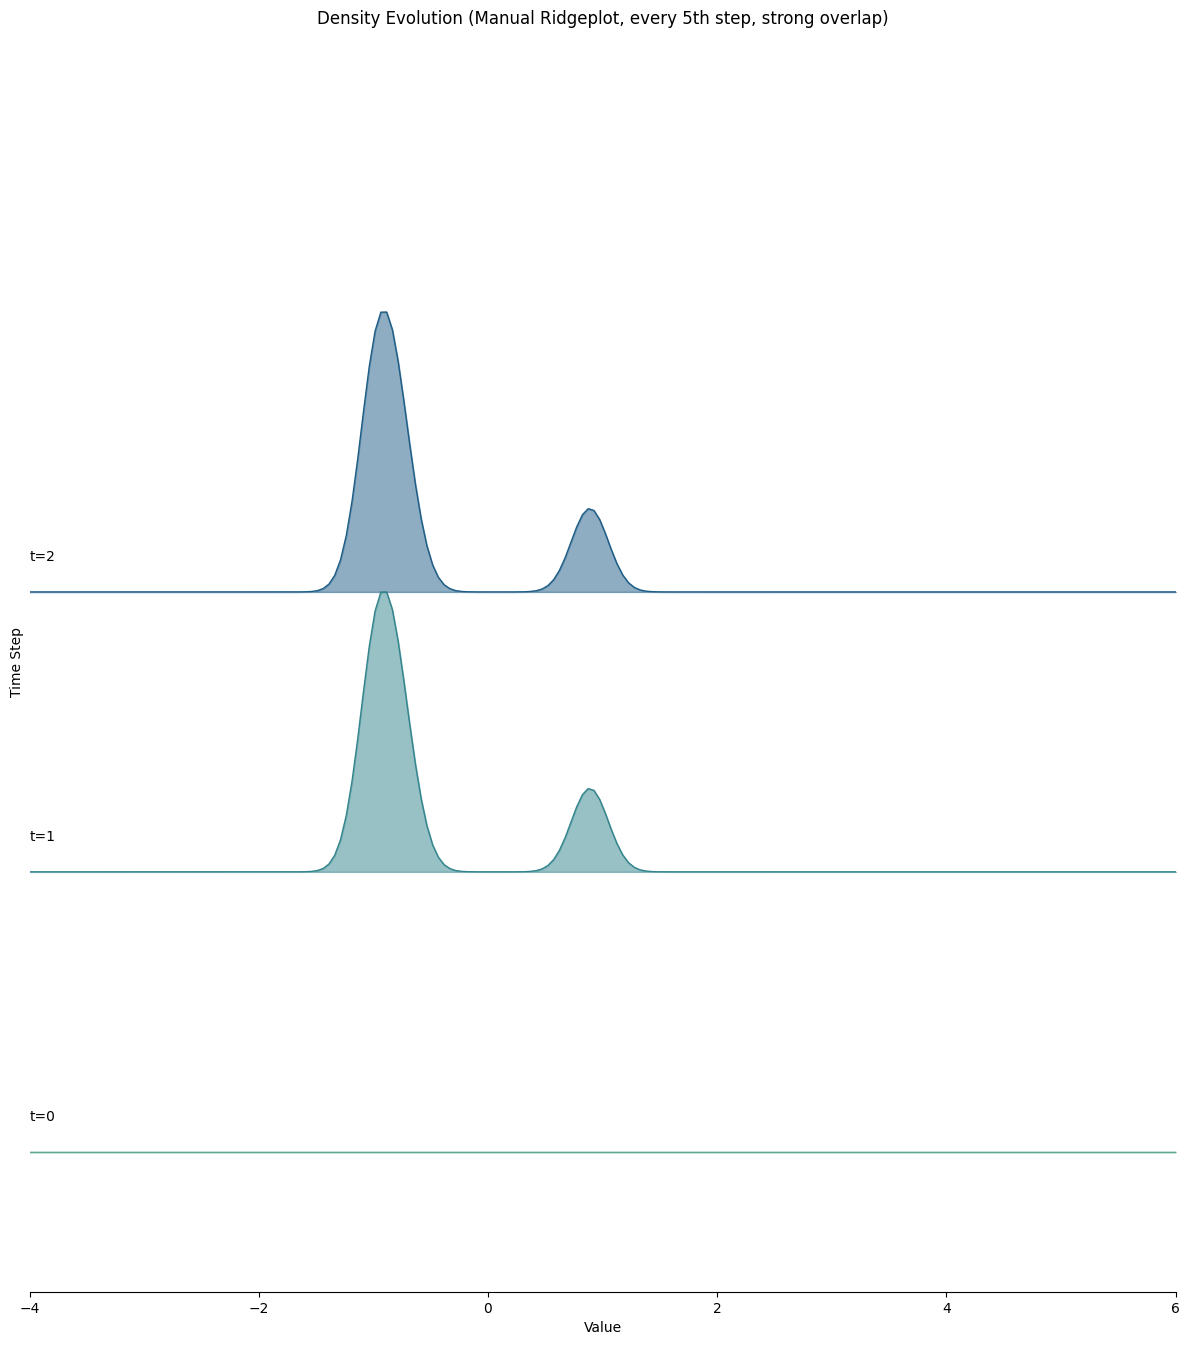

In [153]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde


def plot_trajectory_densities(plotted_trajectories):
    fig = plt.figure(figsize=(12, 20))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2])

    # Plot 1: Individual trajectories

    # Plot 2: Manual ridgeplot, every 5th time step, strong overlap
    ax2 = fig.add_subplot(gs[1])
    step = 1

    selected_indices = np.arange(0, plotted_trajectories.shape[0] + 1, step)
    n_ridges = len(selected_indices)
    # Use a more subtle color palette
    colors = sns.color_palette("crest", n_ridges)

    # Restrict x range to where the data is not flat
    x_min, x_max = -4, 6
    x_grid = np.linspace(x_min, x_max, 200)
    vertical_scale = 1.0  # Increase for more overlap
    offset = 1.0  # vertical offset between ridges

    for i, t in enumerate(selected_indices):
        values = plotted_trajectories[t, :]
        # Filter out any NaN or infinite values
        values = values[~np.isnan(values) & ~np.isinf(values)]

        # Add small jitter to break degeneracy
        jitter = np.random.normal(0, 1e-6, size=len(values))
        values = values + jitter
        kde = gaussian_kde(values, bw_method=0.2)
        density = kde(x_grid)
        # Normalize and scale for strong overlap
        if density.max() > 0:
            density = density / density.max() * vertical_scale
        ax2.fill_between(
            x_grid, i * offset, i * offset + density, color=colors[i], alpha=0.5
        )
        ax2.plot(x_grid, i * offset + density, color=colors[i], lw=1)
        ax2.text(x_min, i * offset + 0.1, f"t={t}", va="bottom", ha="left", fontsize=10)

    ax2.set_yticks([])
    ax2.set_ylabel("Time Step")
    ax2.set_xlabel("Value")
    ax2.set_title(
        "Density Evolution (Manual Ridgeplot, every 5th step, strong overlap)"
    )
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(-0.5, n_ridges * offset + vertical_scale)
    sns.despine(ax=ax2, left=True, bottom=False)

    plt.tight_layout()
    plt.show()


# Example usage:
plot_trajectory_densities(particles)
# particles.shape